In [1]:
from numba import cuda
import numpy as np
import matplotlib.pyplot as plt
from time import time

In [4]:
device = cuda.get_current_device()
device_name = device.name
if isinstance(device_name, bytes):
    device_name = device_name.decode('utf-8')

compute_capability = device.compute_capability
multiprocessor_count = getattr(device, "MULTIPROCESSOR_COUNT")
core_count = 108*64 # Ampere architecture
free_memory, total_memory = cuda.current_context().get_memory_info()
memory_size = total_memory

print(f"Device Name: {device_name}")
print(f"Compute Capability: {compute_capability[0]}.{compute_capability[1]}")
print(f"Core Count: {core_count}")
print(f"Multiprocessor Count: {multiprocessor_count}")
print(f"Memory Size: {memory_size} bytes")

Device Name: NVIDIA A100-SXM4-40GB
Compute Capability: 8.0
Core Count: 6912
Multiprocessor Count: 108
Memory Size: 42405855232 bytes


In [ ]:
select_cuda=cuda.select_device(0)
print(f"Select cuda: {select_cuda}")

Select cuda: <CUDA device 0 'NVIDIA A100-SXM4-40GB'>


In [ ]:
select_cuda=cuda.select_device(1)
print(f"Select cuda: {select_cuda}")

IndexError: list index out of range

In [2]:
@cuda.jit
def grayscale_gpu(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

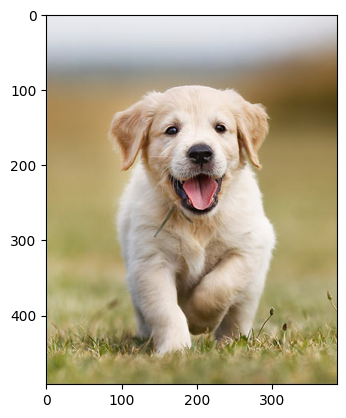

In [3]:
img_src = "/content/drive/MyDrive/DATA/HPC/image.jpg"
img=plt.imread(img_src, format=None)
plt.imshow(img)
plt.show()

In [4]:
# Flatten image into 1D array of RGB
pixel_count = img.shape[0] * img.shape[1]
img_flat = img.reshape(pixel_count, 3)

print(f"Shape of flattened image: {img_flat.shape}")

Shape of flattened image: (190404, 3)


### Grayscale Conversion using CPU

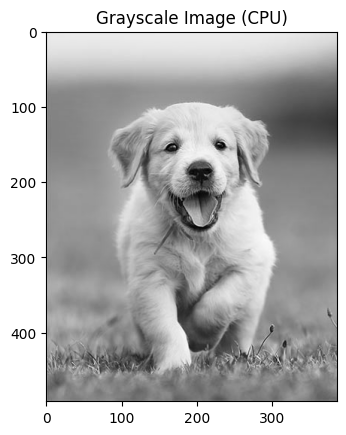

CPU Grayscale conversion took: 1.3464 seconds


In [5]:
def grayscale_cpu(image):
    gray_image = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            avg = np.mean(image[i, j])
            gray_image[i, j] = [avg, avg, avg]
    return gray_image

start_time_cpu = time()
gray_image_cpu = grayscale_cpu(img)
end_time_cpu = time()

plt.imshow(gray_image_cpu)
plt.title('Grayscale Image (CPU)')
plt.show()

print(f"CPU Grayscale conversion took: {end_time_cpu - start_time_cpu:.4f} seconds")

### Grayscale Conversion using GPU (Numba CUDA)

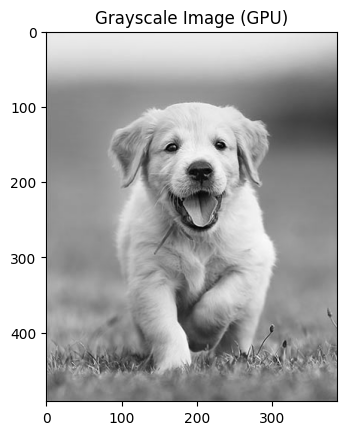

GPU Grayscale conversion took: 0.0004 seconds


In [15]:
img_flat = np.array(img_flat, copy=True)
gray_flat = np.zeros_like(img_flat)

threads_per_block = 64
blocks_per_grid = (pixel_count + threads_per_block - 1) // threads_per_block

d_img = cuda.to_device(img_flat)
d_gray = cuda.to_device(gray_flat)

start_time_gpu = time()

grayscale_gpu[blocks_per_grid, threads_per_block](d_img, d_gray)

cuda.synchronize()

end_time_gpu = time()

gray_flat = d_gray.copy_to_host()
gray_image_gpu = gray_flat.reshape(img.shape)

plt.imshow(gray_image_gpu)
plt.title('Grayscale Image (GPU)')
plt.show()

print(f"GPU Grayscale conversion took: {end_time_gpu - start_time_gpu:.4f} seconds")